# Likelihood-based calibration of hydrological models

This notebook discusses the likelihood-based approach of calibrating hydrological models. 
This approach provides an alternative to the use of goodness-of-fit calibration criteria such as the Nash-Sutcliffe Efficiency (NSE) and allows for systematically identifying 
an appropriate objective function for calibration, by linking the objective function, i.e. the likelihood, to the underlying statistical assumptions it is based on.

An attractive feature of this approach is that it follows the scientific cycle of 
(i) building a model, 
(ii) checking performance of the model against data, 
(iii) going back to step 1 to revise initial assumptions in the model. 

We simply extend the notion of our "model" to not only denote the hydrological model itself but also any other (probabilistic) assumptions we make about the data. 
As a bonus, we get estimates of uncertainty in the model predictions for free. It can be argued that this is in fact an essential feature, i.e. that you should never provide deterministic model predictions.

The approach will be explored using the data and the HBV model from a previous modeling exercise.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from HBVMod import HBVMod #the rainfall-runoff model
from scipy.optimize import differential_evolution#the calibration algorithm
from scipy.stats import norm #the normal distribution
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
import pandas as pd
from pathlib import Path
from cartopy.io import shapereader
from rich import print
import matplotlib.pyplot as plt
import xarray as xr

LOADING OUR DATA Cagayan De Oro

In [3]:
# Name of shapefile/region
own_region = "Cagayan_de_Oro"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_1991_2019_Forcing"

#Shape area
shape_area_Cagayan = 1083.18 * 1000000 # m2

# Load ERA5 data
ERA5_forcing_Cagayan = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)

#forcing = np.genfromtxt('Forcing.txt', dtype=float, autostrip=True)
#forcing = forcing[:,3:6]
#P = forcing[:,0]
#Ep = forcing[:,2]
#Qobs = forcing[:,1]

In [4]:
# Load evap and prec Cagayan de Oro
C_evap = ERA5_forcing_Cagayan.to_xarray()["evspsblpot"]
C_prec = ERA5_forcing_Cagayan.to_xarray()["pr"]
C_evap = C_evap * 86400 # mm/day
C_prec = C_prec * 86400 # mm/day

In [5]:
C_evap["time"] = C_evap["time"].dt.date
C_prec["time"] = C_prec["time"].dt.date

In [6]:
# Discharge data Cagayan de Oro
C_obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])
C_obs = C_obs / 1000 # m3/s
C_obs = C_obs * 86400 / shape_area_Cagayan * 1000 # mm/day
C_obs.loc[C_obs['Q'] > 4000, 'Q'] = np.nan
C_obs_data = C_obs['Q'].to_xarray().rename({'Day': 'time'})

In [7]:
C_evap.name = "EP mm/d" 
C_prec.name = "P mm/d"
C_obs_data.name = "Q mm/d"

df = xr.merge([C_prec, C_evap, C_obs_data]).to_dataframe()
Cagayan = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
Cagayan.index = pd.to_datetime(Cagayan.index)
Cagayan

,P mm/d,EP mm/d,Q mm/d
time,,,
1991-01-16,2.945107,2.031221,3.533596
1991-01-17,1.071095,2.083669,3.190605
1991-01-18,2.552277,2.799082,3.190605
1991-01-19,13.945623,1.719752,3.190605
1991-01-20,15.782014,2.488085,3.190605
...,...,...,...
2019-12-27,3.364178,3.098087,4.044890
2019-12-28,1.434635,3.548304,3.810381
2019-12-29,0.544718,3.392103,3.598205


In [8]:
#          Imax    Ce        Sumax      beta      Pmax          Tlag     Kf           Ks
bounds = [(0, 8), (0.2, 1), (40, 800), (0.5, 4), (0.001, 0.3), (0, 10), (0.01, 0.1), (0.0001, 0.01)]

# Function that takes in a parameter vector, runs the model, and returns the time-series of simulated runoff
def run_model(par):
    Sin = np.array([0,  100,  0,  5.0])#initial storages
    return HBVMod(par, P, Ep, Sin)

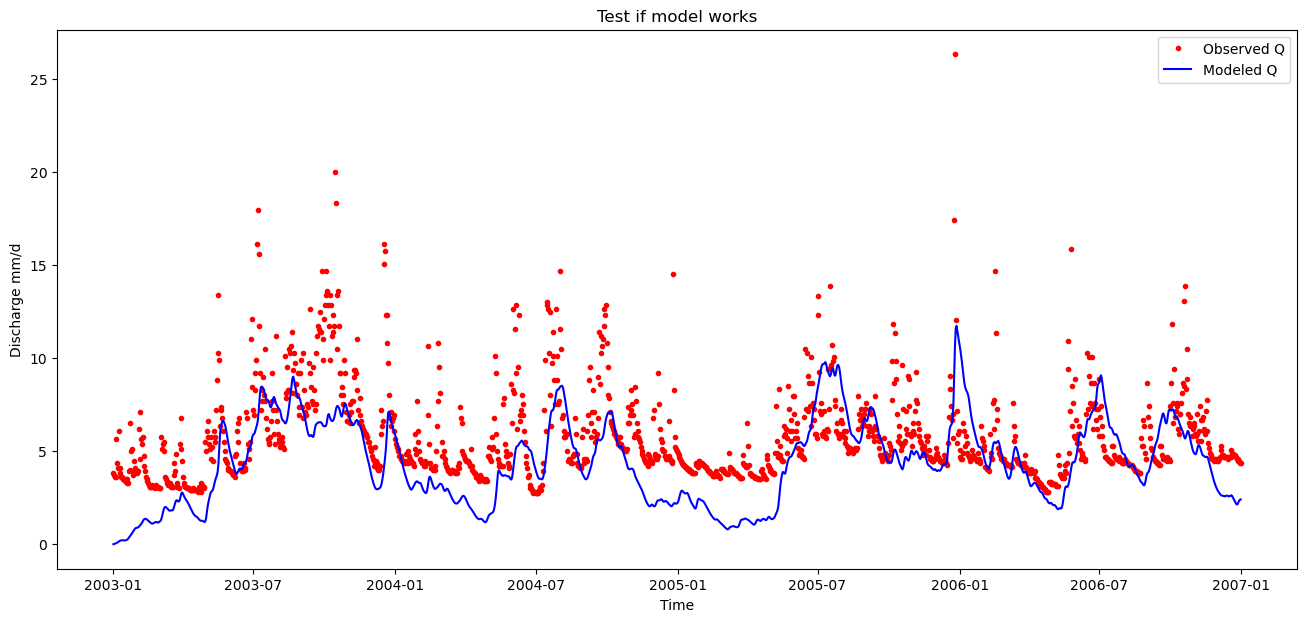

In [9]:
# Quick test to make sure the model runs
par = np.array([4, 0.6, 400, 2, 0.1, 5, 0.05, 0.005])#some arbitrary parameter values
P = Cagayan['P mm/d'].loc['2003-01-01':'2006-12-31']
Ep = Cagayan['EP mm/d'].loc['2003-01-01':'2006-12-31']
Qsim = run_model(par)
Qobs = Cagayan['Q mm/d'].loc['2003-01-01':'2006-12-31']
plt.figure(figsize=(16,7))
plt.plot(Qobs, 'r.', label='Observed Q')
plt.plot(Cagayan.loc['2003-01-01':'2006-12-31'].index, Qsim, 'b', label='Modeled Q')
plt.title('Test if model works')
plt.xlabel('Time')
plt.ylabel('Discharge mm/d')
plt.legend();

## Model calibration using NSE

In [10]:
def neg_NSE(par):
    Qsim = run_model(par)
    sim = Qsim[365:]#exclude first year as warm-up
    obs = Qobs[365:]
    NSE = 1 - np.sum((obs-sim)**2) / np.sum((obs-np.mean(obs))**2)
    return -NSE#return the negative NSE, since we're going to minimize

In [ ]:
# Use differential evolution to minimize the objective function (neg_NSE) by varying the model parameters within the bounds
result = differential_evolution(neg_NSE, bounds)#runs the calibration
par = result.x#grabs the best parameter set
NSE = -neg_NSE(par)#computes NSE for the best parameter set
print(NSE, par)

In [ ]:
Qsim = run_model(par)
plt.figure(figsize=(16,7))
plt.plot(Qobs[365:], 'r.', label='Observed Q')
plt.plot(Cagayan.loc['2004-01-01':'2006-12-31'].index, Qsim[365:], 'b', label='Modeled Q')
plt.title('Calibrated Discharge Model (Cagayan de Oro)')
plt.xlabel('Time')
plt.ylabel('Discharge mm/d')
plt.legend();

## Likelihood-based calibration

### Normal observation model

In [ ]:
# Negative log-likelihood function for normal observation model
def neg_loglik_norm(par):
    Qsim = run_model(par[:-1])#the last parameter is sigma; exclude it when running the model
    sim = Qsim[365:]#ignore first year as warm-up
    obs = Qobs[365:]
    sigma = par[-1]
    logL = np.mean(norm.logpdf(obs, sim, sigma))
    return -logL

In [ ]:
bounds.append((0, 1))#add min-max bounds for sigma
result = differential_evolution(neg_loglik_norm, bounds)
par = result.x
maxloglik = -neg_loglik_norm(par)
print(maxloglik, par)

In [ ]:
Qsim = run_model(par[:-1])
mu = Qsim[365:]
sigma = par[-1]
Q05 = norm.ppf(0.05, mu, sigma)
Q95 = norm.ppf(0.95, mu, sigma)
plt.figure(figsize=(16,7))
plt.plot(Qobs[365:], 'r.', label='Observed Q')
plt.fill_between(Cagayan.loc['2004-01-01':'2006-12-31'].index, Q05, Q95, color='grey', alpha=0.5, label='Confidence interval 5-95')
plt.title('Normal Observational Model')
plt.xlabel('Time')
plt.ylabel('Discharge mm/d')
plt.legend()

### Lognormal observation model

In [ ]:
def neg_loglik_lognorm(par):
    Qsim = run_model(par[:-1])
    sim = Qsim[365:]#ignore first year as warm-up
    obs = Qobs[365:]
    x = np.log(obs)
    CV = par[-1]
    sigma2 = np.log(CV * CV + 1)
    mu = np.log(sim) + sigma2
    sigma = np.sqrt(sigma2)
    logL = -np.mean(x) + np.mean(norm.logpdf(x, mu, sigma)) 
    return -logL

In [ ]:
result = differential_evolution(neg_loglik_lognorm, bounds)
par = result.x
maxloglik = -neg_loglik_lognorm(par)
print(maxloglik, par)

In [ ]:
Qsim = run_model(par[:-1])
CV = par[-1]
sigma2 = np.log(CV * CV + 1)
mu = np.log(Qsim[365:]) + sigma2
sigma = np.sqrt(sigma2)
Q05 = np.exp(norm.ppf(0.05, mu, sigma))
Q95 = np.exp(norm.ppf(0.95, mu, sigma))
plt.figure(figsize=(16,7))
plt.fill_between(Cagayan.loc['2004-01-01':'2006-12-31'].index, Q05, Q95, color='grey', alpha=0.5, label='Confidence interval 5-95')
plt.plot(Qobs[365:], 'r.', label='Observed Q')
plt.title('Lognormal Observational Model')
plt.xlabel('Time')
plt.ylabel('Discharge mm/d')
plt.legend()